# CSCE 479/879 Hackathon: Recurrent Models

Written by Eleanor Quint

Modified by Mrinal Rawool and Stephen Scott

Topics to be covered:
- Sentiment analysis using an LSTM-based network
- Sentiment analysis using an LSTM + attention mechanism
- Introducing the Transformer architecture
- Textual entailment classification using a pretrained Transformer model


In [ ]:
# We'll start with our library imports...
from __future__ import print_function

import numpy as np                 # to use numpy arrays
import tensorflow as tf            # to specify and run computation graphs
import tensorflow_datasets as tfds # to load training data
import matplotlib.pyplot as plt    # to visualize data and draw plots
from tqdm import tqdm              # to track progress of loops

# DATA_DIR = './tensorflow-datasets/'

In [ ]:
import sys
print(sys.executable) # should print /mnt/nrdstor/cse420/shared/cse420-uvenv/.venv/bin/python 

#### RNN/LSTM recap

Recurrent neural networks (RNNs) are computation graphs with loops (i.e., not directed acyclic graphs). Because backpropagation only works with DAGs, we have to unroll the RNN through time when training. TensorFlow provides code that handles this automatically.

<img src="http://colah.github.io/posts/2015-08-Understanding-LSTMs/img/RNN-unrolled.png" width="80%">


The most common RNN unit is the LSTM, depicted below:

<img src="http://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-chain.png" width="80%">

We can see that each unit takes 3 inputs and produces 3 outputs, two which are forwarded to the same unit at the next timestep and one true output, $h_t$, depicted coming out of the top of the cell.

The upper right output going to the next timestep is the cell state. It carries long-term information between cells, and is calculated as:

<img src="http://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-focus-C.png" width="80%">

where the first term uses the forget gate $f_t$ to decide to scale the previous state (potentially making it smaller to "forget" it), and the second term is the product of the update gate $i_t$ and the state update $\tilde{C}_t$. Each of the forget and update gates are activated with sigmoid, so their range is (0,1).

The true output and the second, lower output on the diagram are calculated by the output gate:

<img src="http://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-focus-o.png" width="80%">

First, $o_t$ is calculated from the output of the previous timestep concatenated with the current input, but then it's mixed with the cell state to get the true output. Passing on this output to the next timestep as the hidden state gives the unit a kind of short term memory.

(Images sourced from [Colah's Blog](http://colah.github.io/posts/2015-08-Understanding-LSTMs/))

### Tasks

#### Sentiment analysis task:

Sentiment Analysis is the task of classifying the polarity of a given text.

### Demo: Sentiment Classification using LSTMs

Today, we're going to teach a recurrent model how to classify sentiment by inputting a sequence of words and asking the model to estimate what the sentiment is. The IMDB review dataset has the text of movie reviews and a label for whether the review is negative (zero) or positive (one). First, we'll load the dataset and then set up a preprocessor to turn the words into integers using `tf.keras.layers.experimental.preprocessing.TextVectorization`.

The workflow looks like this:

Raw text -> Vectorization/ Tokenization (word/ word-piece to int) -> Embeddings (int to embedding vector) -> Other model layers -> Model output layer -> Output

#### Step 1: Download and examine the dataset



In [ ]:
from datasets import load_dataset

In [ ]:
# load IMDB dataset
dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

In [ ]:
imdb_train_valid = dataset['train'].select(range(500)).train_test_split(0.2)
imdb_train, imdb_validation = imdb_train_valid['train'], imdb_train_valid['test']
imdb_test = dataset['test'].select(range(50))

imdb_train, imdb_validation, imdb_test

In [ ]:
train_texts = imdb_train["text"]

In [ ]:
for item in imdb_train.take(1):
    print(item["text"], "\n", item["label"])

#### Step 2: Create vectorization layer

to create a word <=> integer mapping


In [ ]:
# vectorization hyperparams
MAX_SEQ_LEN = 128
MAX_TOKENS = 5000

# Create TextVectorization layer
vectorize_layer = tf.keras.layers.TextVectorization(max_tokens=MAX_TOKENS,
                                                    # standardize='lower_and_strip_punctuation',
                                                    # split='whitespace',
                                                    # ngrams=None,
                                                    # output_mode='int', # options: "int", "multi_hot", "count" or "tf_idf"
                                                    output_sequence_length=MAX_SEQ_LEN,
                                                    # pad_to_max_tokens=False,
                                                    # vocabulary=None,
                                                    # idf_weights=None,
                                                    # sparse=False,
                                                    # ragged=False,
                                                    # encoding='utf-8',
                                                    # **kwargs
                                                    )
# ignore CUDA Runtime error

 When this layer is adapted, it will analyze the dataset, determine the frequency of individual string values, and create a vocabulary from them.

In [ ]:
# Use `adapt` to create a vocabulary mapping words to integers

vectorize_layer.adapt(train_texts)


In [ ]:
vectorize_layer.vocabulary_size() # due to max tokens limit

In [ ]:
vectorize_layer.get_config()

In [ ]:
print(vectorize_layer.get_vocabulary()[:10]) # most freq words
print(vectorize_layer.get_vocabulary()[-10:]) # least freq words

#### Step 3: Apply Vectorization layer to a batch of the dataset


In [ ]:
vectorize_output = vectorize_layer("This is an example.")

You might notice that the integer representation of each sentence ends in zeroes. To ensure that each input the same shape, the end of the sequence is padded with zeros. This is determined by MAX_SEQ_LEN and should typically be as long as the longest sequence in your dataset. The MAX_TOKENS value helps the TextVectorizer to pre-allocate a number of values to assign tokens to.

In [ ]:
vectorize_output # padding because we have provided a max seq length

In [ ]:
# Let's print out a batch to see what it looks like in text and in integers
for batch in imdb_train.batch(1):
    text = batch['text']
    print(list(zip(text, vectorize_layer(text).numpy())))
    break

#### The need for embedding layer


Now each word in the sequence is represented as an integer. However, this discrete representation fails to capture any semantic relationships between words. I.e., the model wouldn't know that "crimson" and "scarlet" are more similar than "red" and "blue". The solution is to learn an word embedding as the first part of the model to transform each integer into a relatively small, dense vector (as compared to a one-hot). Then, similar words will train to have similar embedded representations. A more sophisticated model might use a pre-trained word embedding like [BERT](https://blog.google/products/search/search-language-understanding-bert/).



#### Step 4: Create an Embedding layer

We'll use [tf.nn.embedding_lookup](https://www.tensorflow.org/api_docs/python/tf/nn/embedding_lookup) to do this which we provide a trainable VOCAB_SIZE x EMBEDDING_SIZE matrix. This will learn an embedding from your dataset with training gradients.

A typical dictionary entry looks like
```
<word-idx> <word> = <a phrase that expresses its meaning>
```
This is implemented in two steps in NLP
1. **Tokenizer** assigns an index to each token or word ```<id> <token>```
2. **Embedding** assigns a numeric tensor (float) to each token ```<id> <n dimensional tensor>```

In [ ]:
# embedding layer parameters
VOCAB_SIZE = len(vectorize_layer.get_vocabulary()) # eg 100
EMBEDDING_SIZE = int(np.sqrt(VOCAB_SIZE)) # 10 This ensures that the embedding matrix is dense
print("Vocab size is {} and is embedded into {} dimensions".format(VOCAB_SIZE, EMBEDDING_SIZE))

embedding_layer = tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_SIZE)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sample_text = "This is an example"
vectorized_text = vectorize_layer(sample_text)
embedding_text = embedding_layer(vectorized_text)
print(embedding_text.shape) # (128, 70) 128 is the MAX_SEQ_LEN

In [ ]:
id_token_map = vectorize_layer.get_vocabulary()
len(id_token_map)

In [ ]:
ytick_labels = [id_token_map[id] for id in vectorized_text[:6]]
ytick_labels

In [ ]:

ax = sns.heatmap(embedding_text[:6], yticklabels=ytick_labels) # first 6 tokens

ax.set(xlabel ="Embedding Dimensions", ylabel = "Text tokens", title ="Visualize embeddings")
plt.show()


#### A brief note on how Recurrent network APIs are implemented in TF

[Tensorflow RNNs](https://www.tensorflow.org/guide/keras/working_with_rnns)

RNN layers ([keras.layers.SimpleRNN](https://www.tensorflow.org/api_docs/python/tf/keras/layers/SimpleRNN) | [keras.layers.GRU](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU) | [keras.layers.LSTM](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM)) 

v/s 

RNN Cells ([tf.keras.layers.SimpleRNNCell](https://www.tensorflow.org/api_docs/python/tf/keras/layers/SimpleRNNCell) | [tf.keras.layers.GRUCell](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRUCell) | [tf.keras.layers.LSTMCell](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTMCell))

Layers can process batches of input sequences.

Cells process a single timestep.

Mathematically, RNN(LSTMCell(10)) produces the same result as LSTM(10). However using the built-in GRU and LSTM layers enable the use of CuDNN and you may see better performance.


In [ ]:
# Example 1: using a cell instance
inputs = np.random.random((32, 10, 8))
# tf.keras.layers.RNN is a wrapper that allows customization of what happens inside the RNN layer
# tf.keras.layers.RNN can be instantiated using a RNN cell instance or a list of RNN cell instances.
rnn = tf.keras.layers.RNN(tf.keras.layers.LSTMCell(4)) # 4 is the output dimension of LSTM cell
output = rnn(inputs)
output.shape

In [ ]:
# Example 2: Using a list of cells
inputs = np.random.random((32, 10, 8))
# tf.keras.layers.RNN can be instantiated using a RNN cell instance or a list of RNN cell instances.
rnn = tf.keras.layers.RNN([tf.keras.layers.LSTMCell(256), tf.keras.layers.LSTMCell(64)])
output = rnn(inputs)
output.shape

When RNN layer is created as above, i.e by passing a list of LSTM cell instances, a [stacked RNN layer](https://github.com/keras-team/keras/blob/v3.3.3/keras/src/layers/rnn/rnn.py) (StackedRNNCells‎) gets created. A stacked RNN has multiple hidden layers allowing them to abstract more information from the input at each time step and pass it on to the next layer. For a timestep `t`, a layer `L` calculates its hidden state `h(t)(L)` using its input, previous hidden state `h(t-1)(L)`. The next layer `L+1` calculates its hidden state `h(t)(L+1)` using its input `h(t)(L)` (Note that this is the hidden state of the previous layer of the RNN stack), and its own previous hidden state `h(t-1)(L+1)`.

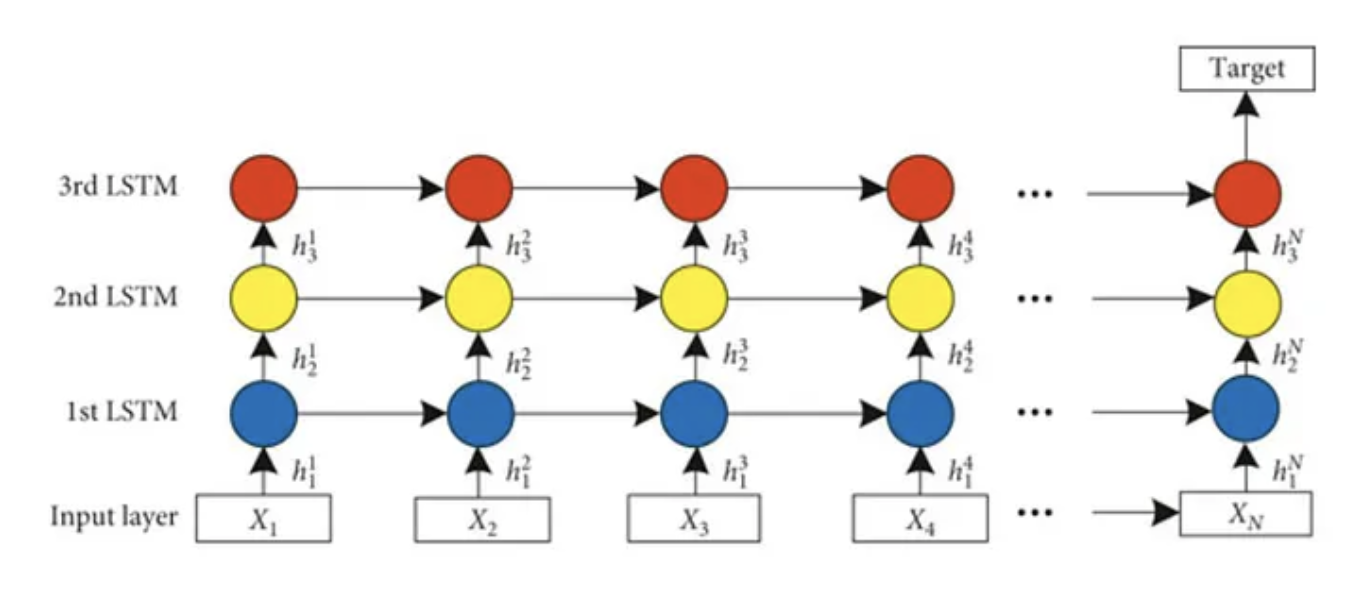


Image courtesy [this article](https://python.plainenglish.io/stacked-rnns-in-nlp-936e6eecf37a)

#### Step 5: Building a classifier model using Recurrent layer

TensorFlow separates the declaration of RNNCells from the [RNNs](https://www.tensorflow.org/api_docs/python/tf/keras/layers/RNN) that run them. In the code below, we declare two [LSTM cells](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTMCell) and pass them both to the RNN to be run together.

In [ ]:
# Build the model

# We create a list of LSTM cell instances with output dim 256 and 64. 
# Then we use an RNN layer wrapper around these LSTM cells. This allows the model to process batches of input sequences.
# The below line of code creates two LSTM cells (capable of processing a timestep)
cells = [tf.keras.layers.LSTMCell(256), tf.keras.layers.LSTMCell(64)]
# we then wrap the cells inside an RNN layer which is capable of processing an input sequence.
rnn = tf.keras.layers.RNN(cells) 
# finally, we use a dense layer as the output layer
output_layer = tf.keras.layers.Dense(2)

model = tf.keras.Sequential([vectorize_layer, embedding_layer, rnn, output_layer])

# _ = model(["sample input"])
text = tf.constant(["sample input"])
_ = model(text)
model.summary()

In [ ]:
# TF requires dataset to be in tf.data.dataset format while the dataset is currently in Huggingface Dataset format.
# so lets convert it into TF compatible format.
imdb_train_tf = imdb_train.to_tf_dataset(
    columns=["text"],
    label_cols=["label"],
    batch_size=2,
    shuffle=True
) # ignore warnings

In [ ]:
imdb_train_tf

In [ ]:
# observe the structure of the dataset after format conversion
for batch in imdb_train_tf:
    print(len(batch))
    print(type(batch[1]))
    print(batch[0].shape)
    print(batch[1].shape)
    print(batch[1])
    break

In [ ]:
# observe the structure of the dataset after format conversion
for batch in imdb_train_tf.batch(1): # adds an additional dimension.
    print(len(batch))
    print(type(batch[1]))
    print(batch[0].shape)
    print(batch[1].shape)
    print(batch[1])
    break

In [ ]:
# test a forward pass
for batch_texts, batch_labels in imdb_train_tf:

    for text, label in zip(batch_texts, batch_labels):
        print(text.numpy()[:100], '... label=', label.numpy())

    print("===========")
    logits = model(batch_texts) # output layer will yeild logits i.e raw probabilities
    # logits = model(batch['text']) # output layer will yeild logits i.e raw probabilities
    print("Batch      :", len(batch_texts)) # it depends on the batch size mentioned above
    print("Batch label:", len(batch_labels))
    print("===========")
    print("Vectorize  :", vectorize_layer(batch_texts).shape)
    print("Embedding  :", embedding_layer(vectorize_layer(batch_texts)).shape)
    print("Recurrent  :", rnn(embedding_layer(vectorize_layer(batch_texts))).shape)
    print("Dense (out):", output_layer(rnn(embedding_layer(vectorize_layer(batch_texts)))).shape)
    print("===========")
    print("Logits     :", logits.numpy())
    print("Probas     :", tf.nn.softmax(logits).numpy())
    print("Predictions:", np.argmax(tf.nn.softmax(logits), axis=-1))
    print("True label :", batch_labels.numpy())

    loss = tf.keras.losses.binary_crossentropy(tf.one_hot(batch_labels, 2, axis=-1), logits, from_logits=True)
    print("BCE loss   :", loss)

    break

Then, to do sentiment analysis, we'll treat this as a classification problem. Because it's only a 2-class problem, we'll use binary cross-entropy and output only one value. Then the output is treated as class zero if it's $<0.5$ and class one if it's $\geq0.5$. We can train this model in the usual way.



### Sentiment analysis using Attention mechanism and LSTMs

One way to enhance the performance of sequential models is a mechanism called attention. Essentially, the idea is that in order to process the meaning of a token correctly, it might rely on tokens far away in the sequence. We're going to use Luong-style attention, which is a classic variety first employed in language translation. It's implemented by `tf.keras.layers.Attention`.

#### Block diagram of the network using attention mechanism

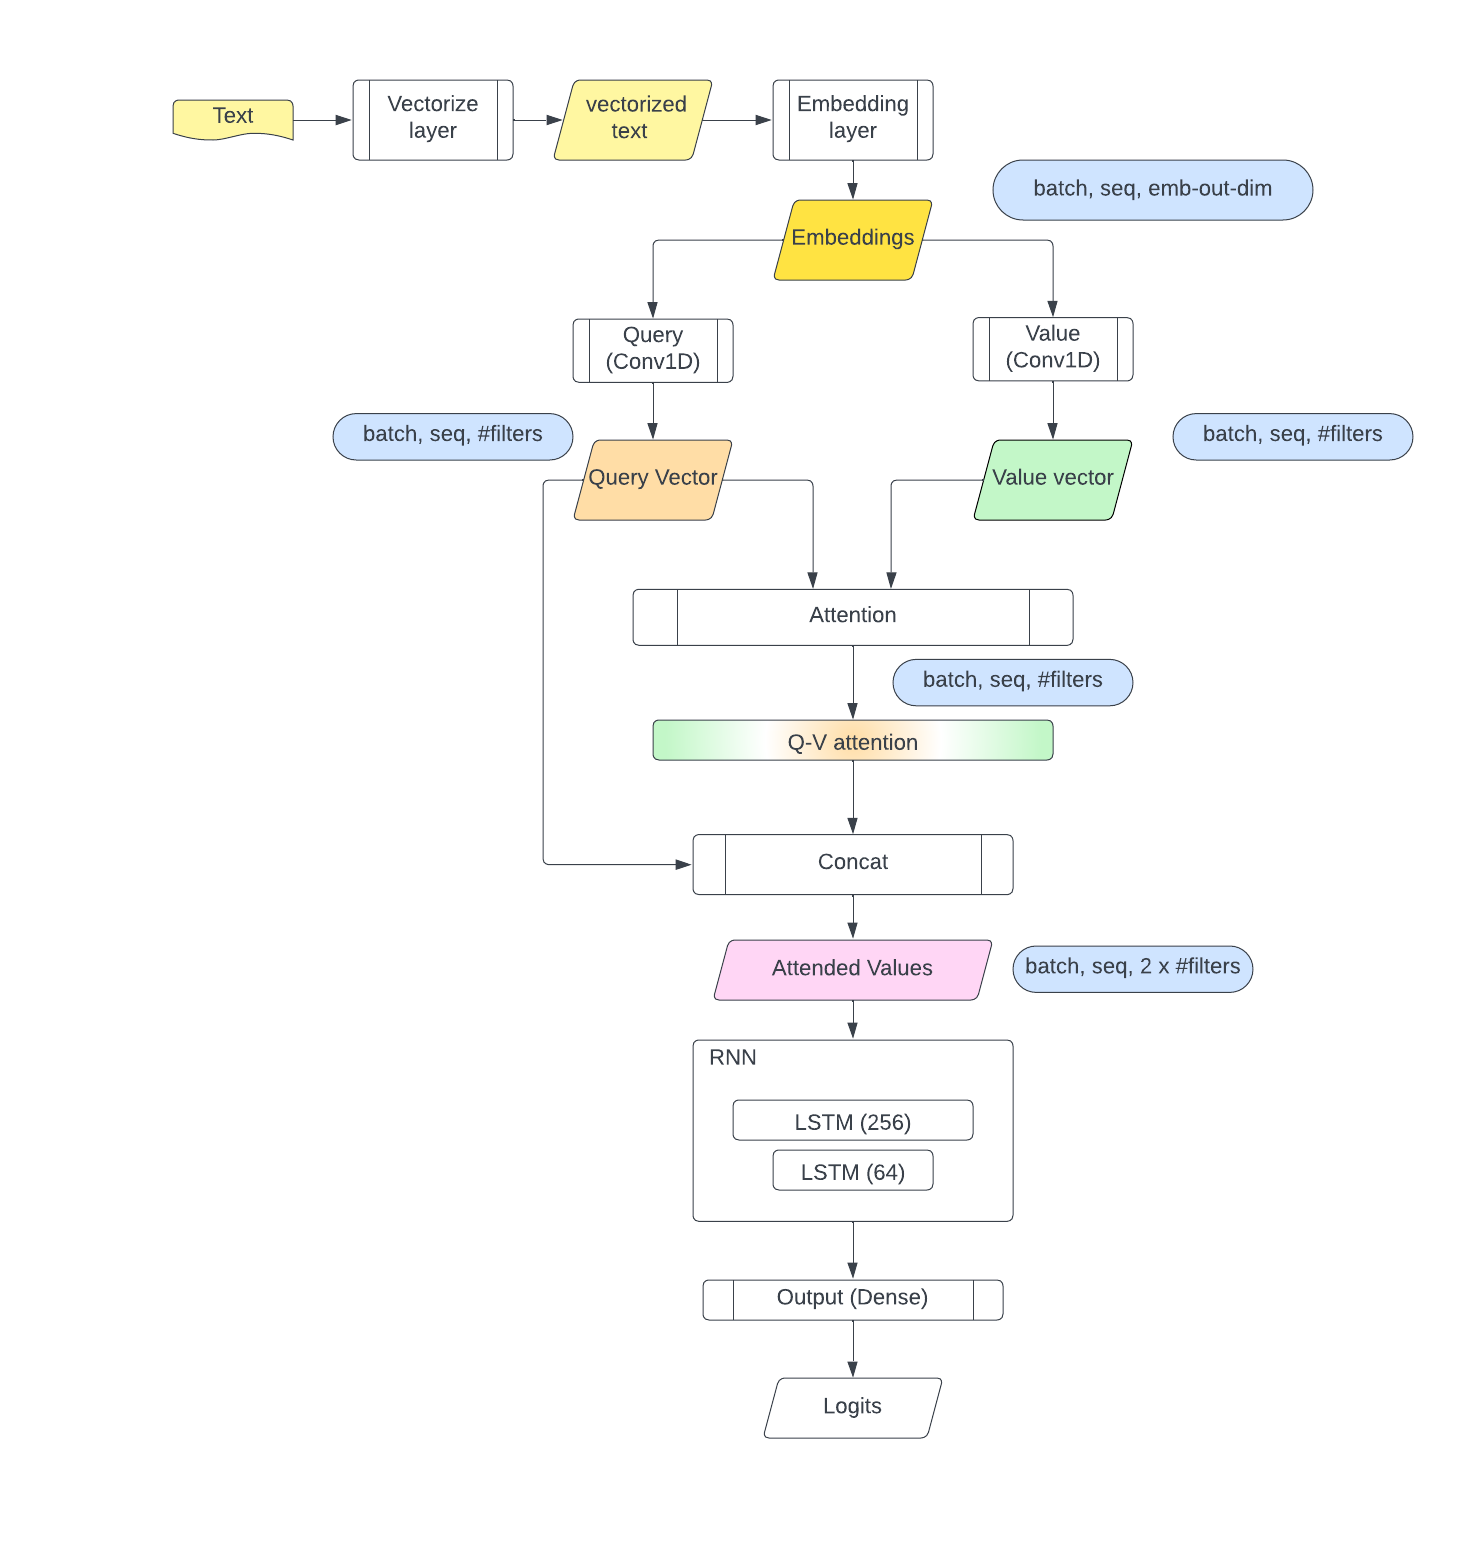

#### Build the model

In [ ]:
# We'll make a conv layer to produce the query and value tensors
query_layer = tf.keras.layers.Conv1D(
    filters=100,
    kernel_size=4,
    padding='same')
value_layer = tf.keras.layers.Conv1D(
    filters=100,
    kernel_size=4,
    padding='same')
# Then they will be input to the Attention layer
attention = tf.keras.layers.Attention()
concat = tf.keras.layers.Concatenate()

cells = [tf.keras.layers.LSTMCell(256), tf.keras.layers.LSTMCell(64)]
rnn = tf.keras.layers.RNN(cells)
output_layer = tf.keras.layers.Dense(1)


In [ ]:
for batch_texts, batch_labels in imdb_train_tf:
    print(batch_texts) # batch of two samples at a time
    print("===========")
    text = batch_texts
    embeddings = embedding_layer(vectorize_layer(text))
    print("Embedding: ", embeddings.shape)
    query = query_layer(embeddings)
    print("Query: ", query.shape)
    value = value_layer(embeddings)
    print("Value: ", value.shape)
    # Checkout the note below to understand how attention scores are calculated.
    query_value_attention = attention([query, value]) # list of tensors. 
    print("Shape after attention: ", query_value_attention.shape)
    attended_values = concat([query, query_value_attention])
    print("Shape after concatenating: ", attended_values.shape)
    logits = output_layer(rnn(attended_values))
    loss = tf.keras.losses.binary_crossentropy(tf.expand_dims(batch_labels, -1), logits, from_logits=True)
    print("Loss: ", loss)
    break

#### Stepping into calculating attention vector

A brief note on how attentions are calculated using [tf.keras.layers.Attention()](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Attention)

Inputs are
1. query tensor of shape [batch_size (1), Tq (128), dim (70)],
2. value tensor of shape [batch_size (1), Tv (128), dim (70)] and
3. key tensor of shape [batch_size, Tv, dim] (same as query in this case). The calculation follows the steps:

Calculate
1. **scores** with shape [batch_size, Tq, Tv] as a query-key dot product: scores = tf.matmul(query, key, transpose_b=True).=> ```(128 x 70) (70 x 128) => 128 x 128``` and
```scores.shape = (1, 128, 128)```

2. Use scores to calculate a **distribution** with shape [batch_size, Tq, Tv]: distribution = tf.nn.softmax(scores).
```distribution.shape = (1, 128, 128)```

3. Use distribution to create a linear combination of value with shape [batch_size, Tq, dim]: return tf.matmul(distribution, value).
``` distribution.shape = (1, 128, 128)```

4. value.shape = (1, 128, 70) # value are the weights in the scaled dot product matmul((128, 128), (128, 70)) => 128 x 70


In this way we can produce a very similar RNN over a sequence, but incorporate more dynamic relationships betweeen distant tokens.


### 

Thus far, we have learnt how to perform sentiment analysis task which is a NLP classification task using the IMDb dataset and a model built using Tensorflow APIs. While Tensorflow has extensive documentation on how to create models capable of handling different types of NLP tasks, it is worthwhile to look at another popular and widely used library called the [Transformers library by HuggingFace](https://huggingface.co/docs/transformers/en/index). This library provides APIs and tools to easily download and train state-of-the-art pretrained models. Using pretrained models can reduce your compute costs, carbon footprint, and save you the time and resources required to train a model from scratch. These models support common tasks in different modalities, such as NLP, Computer Vision, Audio. Transformers library also supports framework interoperability between PyTorch, TensorFlow, and JAX.

In the next few sections, we will look at the Transformers architecture followed by a quick demo of the Natural Language Inference (NLI) task using [DistilBERT](https://huggingface.co/docs/transformers/en/model_doc/distilbert), a small, fast, cheap and light Transformer model trained by distilling BERT base. It has 40% less parameters than google-bert/bert-base-uncased, runs 60% faster while preserving over 95% of BERT’s performances as measured on the [GLUE language understanding benchmark](https://gluebenchmark.com).

### The Transformer Architecture

A Transformer Block from [this](https://arxiv.org/pdf/1706.03762.pdf) paper

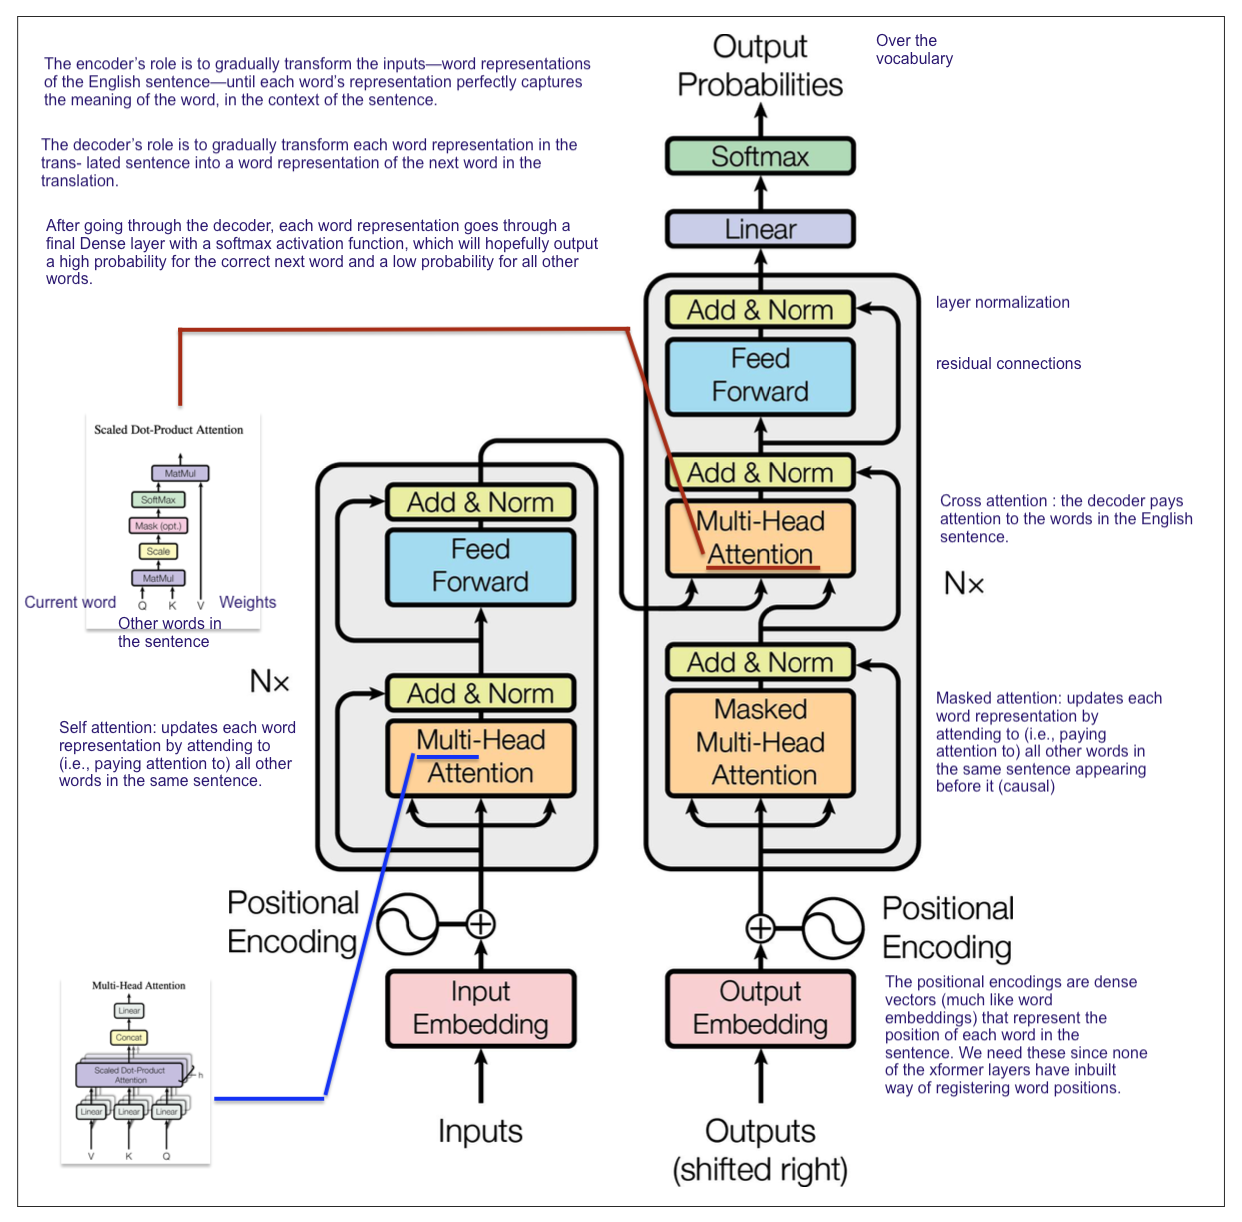

Since models based on Transformer architecture are inherently large, it is a common practice to use pre-trained models from a suitable checkpoint, and finetune it for a desired task. Let's take Distilbert as an example. Generally, the model network consists of

1. Pre-processing layers: These may be part of the model or could be added separately based on the checkpoint being used.
2. Main model layers: This layer group generally starts with input_ids, attention_masks, and token_type_ids (optional) and ends with Attention outputs and pooler outputs that can be consumed by the task oriented layers for prediction or classification.
3. Task oriented layers: These may be part of the model or could be added separately based on the checkpoint being used.

### Demo: Using DistilBert

You can check out [this Github repository](https://github.com/huggingface/transformers/tree/main/examples/research_projects/distillation) for more information on DistilBert

As mentioned before, a model can be made available with or without task heads or language modelling heads. Let's look at two variations of DistiBert to understand this.

HuggingFace offers two checkpoints. The checkpoint "distilbert-base-uncased" is used to access DistilBert base model while chekpoint "distilbert-base-uncased-finetuned-sst-2-english" can be used to access DistilBert finetuned for the SST-2 task.

A task head is a layer or group of layers stacked on top of the base model to train it for a specific task. In the next sub section, we will be using the base model i.e DistilBERT model with its base architecture. 

For the tokenizer, we will be using the from_pretrained() of the AutoTokenizer class. This class instantiates one of the tokenizer classes of the library from a pretrained model vocabulary. The instance to be generated is controoled by the pretrained_model_name_or_path argument which is "distilbert-base-uncased" for the base model and "distilbert-base-uncased-finetuned-sst-2-english" for the task specific model. Every model in HuggingFace comes with its own tokenizer to ensure that the inputs are processed correctly.

#### no task head

In [ ]:
from transformers import DistilBertTokenizer, DistilBertModel
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained("distilbert-base-uncased", attn_implementation="eager")
# dont worry if your kernel dies here. This section is unrelated to the above section so you can continue 
# running cells from this point.


In [ ]:
model # model structure

In [ ]:
model.config # check out hidden_dim, max_position_embeddings, n_heads, n-layers, vocab_size

In [ ]:
text = "Replace me by any text you'd like."
encoded_input = tokenizer(text, return_tensors='pt')
output = model(**encoded_input, output_attentions=True, return_dict=True, output_hidden_states=True)

In [ ]:
output.keys()

In [ ]:
encoded_input # input IDS and attention masts

#### Finetuned model with a task head

In [ ]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification


SST-2 is a sentiment classification dataset derived from  Stanford Sentiment Treebank corpus. In this section, we are going to use Distilbert checkpoint that is finetuned on SST-2 English dataset. You can refer to the [model card](https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english) for details on how the model was trained. 

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english", attn_implementation="eager")


In [ ]:
model # note the last few lines of the summary and compare it with the "no task head" Distilbert above.

In [ ]:
model.config # compare with the config above. For example, this on ehas "label2id"

Let's look at some sample inputs from the dataset. You can check out the dataset [here](https://huggingface.co/datasets/stanfordnlp/sst2)

In [ ]:
inputs = tokenizer("proves once again he has n't lost his touch , bringing off a superb performance in an admittedly middling film .", return_tensors="pt")
with torch.no_grad():
    logits = model(**inputs).logits

predicted_class_id = logits.argmax().item()
model.config.id2label[predicted_class_id]


In [ ]:
inputs = tokenizer("no apparent joy", return_tensors="pt")
with torch.no_grad():
    logits = model(**inputs).logits

predicted_class_id = logits.argmax().item()
model.config.id2label[predicted_class_id]


In [ ]:
inputs = tokenizer("no apparent joy", return_tensors="pt")

outputs = model(**inputs,  output_attentions=True, return_dict=True, output_hidden_states=True)


In [ ]:
inputs

In [ ]:
outputs.keys() # compare with teh no task head version

In [ ]:
predicted_class_id = outputs.logits.argmax().item()
model.config.id2label[predicted_class_id]

#### Visualizing Attentions

In [ ]:
model.eval()

In [ ]:
import matplotlib.pyplot as plt

def plot_attention_heads(attentions, input_ids, tokenizer, layer_num):

    layer_attn = attentions[layer_num][0].detach().cpu().numpy()  # (12, L, L)
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    fig, axes = plt.subplots(4, 3, figsize=(18, 18))

    for head_idx, ax in enumerate(axes.flat):
        im = ax.imshow(
            layer_attn[head_idx],
            aspect="auto",
            vmin=0,
            vmax=1,
            cmap="plasma"   
        )
        
        ax.set_title(f"Head {head_idx}")

        ax.set_xticks(range(len(tokens)))
        ax.set_yticks(range(len(tokens)))

        ax.set_xticklabels(tokens, rotation=90, fontsize=8)
        ax.set_yticklabels(tokens, fontsize=8)

    # Make room for colorbar below last row
    fig.subplots_adjust(bottom=0.12)

    # [left, bottom, width, height]
    cax = fig.add_axes([0.25, 0.05, 0.5, 0.02])
    fig.colorbar(im, cax=cax, orientation="horizontal")

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

In [ ]:
input_text = "no apparent joy"

In [ ]:
inputs = tokenizer(input_text, return_tensors="pt")
outputs = model(**inputs,  output_attentions=True, return_dict=True, output_hidden_states=True) # odict_keys(['logits', 'hidden_states', 'attentions'])

In [ ]:
logits = outputs.logits.detach()
predicted_class_id = logits.argmax().item()
print("Result:")
print(f"Input: {input_text}")
print(f"Label: {model.config.id2label[predicted_class_id]}")

In [ ]:
# check out the confidence of the predictions by converting logits to probabilities.
print('logits: ', logits)
probs = torch.softmax(logits, dim=-1)
print('Probabilities: ', probs)
print(model.config.label2id)

In [ ]:
attentions = outputs.attentions

In [ ]:
print(type(attentions))
print(len(attentions)) # n_layers, 
print(attentions[0].shape) # bsz, n_heads, seqlen, seqlen

In [ ]:
# lets look at all attention heads for a chosen layer
plot_attention_heads(
    attentions,
    inputs["input_ids"],
    tokenizer,
    layer_num=0
)

Rows denote source tokens and Columns denote target tokens. Since this is self attention, both source and target sequence contain the same tokens. Observe how some heads display a clear pattern. Head 1 focusses on the [CLS] token, Head 9 focusses how all token in the sequence attend to the [CLS] token. 

## Helpful links and references

"Attention is all you need"
https://arxiv.org/pdf/1706.03762.pdf

BERT: https://arxiv.org/pdf/1810.04805.pdf

The Illustrated Transformer Blog: http://jalammar.github.io/illustrated-transformer/

# Homework: Does Local Word Order Matter for Sentiment Classification?

You may use either the SST-2 dataset or the IMDB dataset. In this homework, you will run a small experiment to analyze whether a sentiment classification model behaves like a bag-of-words model, or whether local word order affects its predictions.

### Part 1: Dataset-Level Perturbation

Select one split or a small subset of the dataset.

First, run inference on the original samples and record:

* predicted labels
* prediction probabilities
* prediction accuracy

Next, modify the word order in each sample and run inference again. You may design your own perturbation strategy. For example:

* randomly swap two words
* swap adjacent words
* move one word to a random position
* shuffle all words in the sentence

Repeat this experiment with at least two different perturbation strategies.

In your write-up, report:

* what type of word-order change you applied
* how prediction accuracy changed
* how prediction probabilities changed
* whether the model seems robust or sensitive to the perturbation

### Part 2: Manual Analysis of 10 Examples

Handpick 10 short samples from the dataset. For each sample:

* record the original prediction and probability
* create one or more word-order perturbations
* record the new prediction and probability
* inspect the model’s attention outputs before and after perturbation

In your write-up, discuss:

* which examples changed prediction after word-order perturbation
* Did the perturbation modify the meaning of the input sample?
* whether confidence increased or decreased
* whether attention patterns changed noticeably
* whether the model appears to rely on global sentence meaning, local word patterns, or individual sentiment words

For part 2, you may start by experimenting with the example used in the notebook:
```
input_text = "no apparent joy"
```
Try modifying the word order and observe the resulting predictions, probabilities, and attention patterns to help you develop intuition before selecting your own examples for analysis.

Conclude with a short paragraph answering:

**Does this model behave like a bag-of-words model, or does local word order matter? Please support your answer using evidence from your experiments.**




In [ ]:
# download imdb
# dataset = load_dataset("stanfordnlp/imdb")
# download SST-2
# dataset = load_dataset("stanfordnlp/sst2")